## Import and Config

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display, clear_output
from sklearn.decomposition import PCA
from random import uniform
import gc

from diffusers import (
    StableDiffusionXLPipeline,
    StableDiffusionXLControlNetPipeline,
    StableDiffusionXLImg2ImgPipeline,
    ControlNetModel,
    EulerAncestralDiscreteScheduler,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
N = 20


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Load Models

In [ ]:
# ControlNet
controlnet = ControlNetModel.from_pretrained(
    "xinsir/controlnet-scribble-sdxl-1.0",
    torch_dtype=torch.float16
).to(device)

# Sprinter (SDXL Turbo + ControlNet) - generates variations from control images
sprinter = StableDiffusionXLControlNetPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    controlnet=controlnet,
    torch_dtype=torch.float16,
    variant="fp16"
).to(device)

# Architect (SDXL Turbo) - main denoising backbone
architect = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
    variant="fp16"
).to(device)

# Fix VAE precision
architect.vae.to(dtype=torch.float32)
sprinter.vae.to(dtype=torch.float32)

# Monkey-patch sprinter to allow gradients through __call__
original_call = StableDiffusionXLControlNetPipeline.__call__
StableDiffusionXLControlNetPipeline.__call__ = lambda self, *args, **kwargs: (
    original_call.__wrapped__(self, *args, **kwargs)
    if hasattr(original_call, '__wrapped__')
    else original_call(self, *args, **kwargs)
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## Different helper functions

In [ ]:
def sobel_proxy(img_tensor):
    """Differentiable edge detector using Sobel kernels."""
    gray = img_tensor.mean(dim=1, keepdim=True)
    kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], device=device).view(1, 1, 3, 3)
    ky = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], device=device).view(1, 1, 3, 3)
    grad_x = F.conv2d(gray, kx, padding=1)
    grad_y = F.conv2d(gray, ky, padding=1)
    edge_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-6)
    edge_mag = (edge_mag - edge_mag.min()) / (edge_mag.max() - edge_mag.min() + 1e-8)
    return edge_mag.repeat(1, 3, 1, 1)


def compute_mmd(x, y, kernel='rbf', bandwidth=None):
    """MMD^2 with RBF kernel and median heuristic bandwidth."""
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)
    if isinstance(y, np.ndarray):
        y = torch.from_numpy(y)

    dev = x.device
    x, y = x.float().to(dev), y.float().to(dev)

    if x.dim() > 2:
        x = x.reshape(x.shape[0], -1)
    if y.dim() > 2:
        y = y.reshape(y.shape[0], -1)

    n, m = x.shape[0], y.shape[0]

    def rbf_kernel(a, b, bw):
        a_sq = (a ** 2).sum(dim=1, keepdim=True)
        b_sq = (b ** 2).sum(dim=1, keepdim=True)
        dist_sq = a_sq + b_sq.T - 2 * torch.mm(a, b.T)
        return torch.exp(-dist_sq / (2 * bw ** 2))

    if bandwidth is None:
        ss = min(1000, n, m)
        with torch.no_grad():
            x_sq = (x[:ss] ** 2).sum(dim=1, keepdim=True)
            y_sq = (y[:ss] ** 2).sum(dim=1, keepdim=True)
            dists = x_sq + y_sq.T - 2 * torch.mm(x[:ss], y[:ss].T)
            dists = dists[dists > 0]
            bandwidth = torch.sqrt(torch.median(dists) / 2) if len(dists) > 0 else torch.tensor(1.0, device=dev)

    K_xx = rbf_kernel(x, x, bandwidth)
    K_yy = rbf_kernel(y, y, bandwidth)
    K_xy = rbf_kernel(x, y, bandwidth)

    mmd_sq = ((K_xx.sum() - K_xx.trace()) / (n * (n - 1))
              - 2 * K_xy.sum() / (n * m)
              + (K_yy.sum() - K_yy.trace()) / (m * (m - 1)))
    return torch.clamp(mmd_sq, min=0.0)


def freeze_module(module):
    for p in module.parameters():
        p.requires_grad_(False)


def latent_to_pil(sample, vae, image_processor):
    """Decode a single latent to PIL via VAE."""
    sample = sample / vae.config.scaling_factor
    pix = vae.decode(sample.to(vae.dtype)).sample
    return image_processor.postprocess(pix, output_type="pil")[0]

def generate_and_store(pipe, prompt, sobel_cond_pil, num_samples, batch_size=2):
    """Generate images + capture final-step latents."""
    # Temporarily set VAE to float16 for pipeline inference
    original_vae_dtype = pipe.vae.dtype
    pipe.vae.to(dtype=torch.float16)

    all_images, all_lats = [], []

    def latents_callback(p, step_index, timestep, cb_kwargs):
        if step_index == p.num_timesteps - 1:
            p._current_latents = cb_kwargs["latents"].detach().cpu().numpy()
        return cb_kwargs

    for i in range(0, num_samples, batch_size):
        curr = min(batch_size, num_samples - i)
        result = pipe(
            prompt=[prompt] * curr,
            image=[sobel_cond_pil] * curr,
            num_inference_steps=2,
            guidance_scale=0.0,
            controlnet_conditioning_scale=1.0,
            callback_on_step_end=latents_callback,
        )
        all_images.extend(result.images)
        all_lats.append(pipe._current_latents.reshape(curr, -1))
        print(f"  Progress: {len(all_images)}/{num_samples}", end="\r")

    print()


    pipe.vae.to(dtype=original_vae_dtype)

    return all_images, np.vstack(all_lats)

##Magnifyer Pan experiment

###create base shape

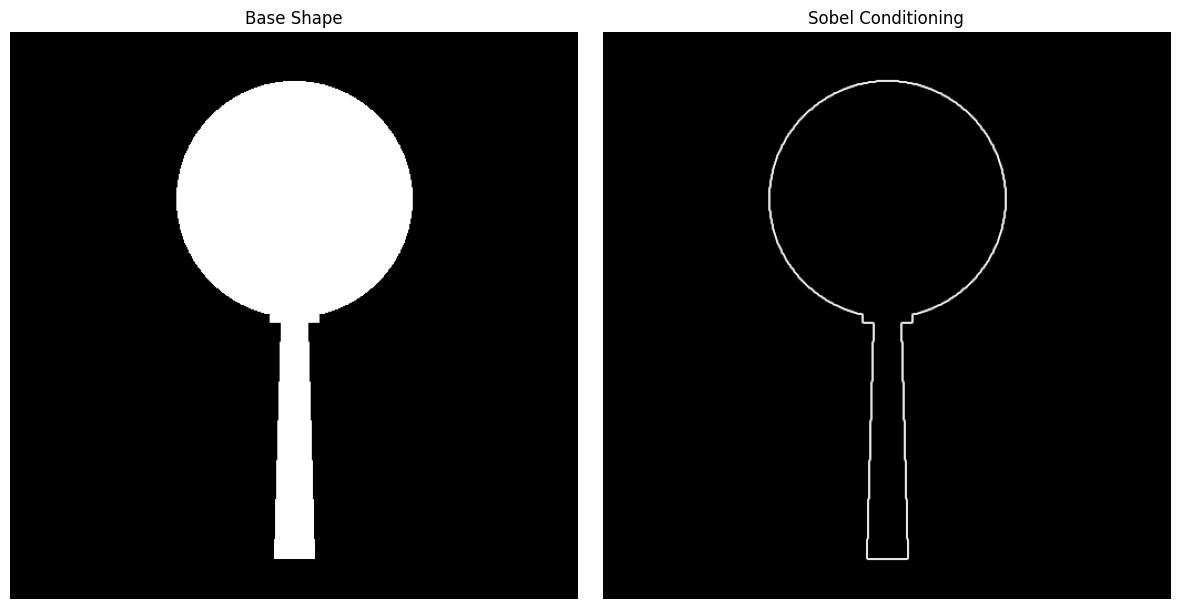

In [ ]:
base_image_pil = Image.new('RGB', (512, 512), color='black')
draw = ImageDraw.Draw(base_image_pil)
draw.ellipse((150, 45, 362, 257), fill='white')       # Oval head
draw.rectangle((234, 241, 278, 262), fill='white')     # Neck
draw.polygon([(244, 262), (268, 262), (274, 475), (238, 475)], fill='white')  # Handle

transform = T.Compose([T.ToTensor()])
base_tensor = transform(base_image_pil).unsqueeze(0).to(device).to(torch.float32)
with torch.no_grad():
    sobel_cond_tensor = sobel_proxy(base_tensor)
    sobel_cond_pil = T.ToPILImage()(sobel_cond_tensor.squeeze(0).cpu())

# Quick visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(base_image_pil); axes[0].set_title("Base Shape"); axes[0].axis('off')
axes[1].imshow(sobel_cond_pil, cmap='gray'); axes[1].set_title("Sobel Conditioning"); axes[1].axis('off')
plt.tight_layout(); plt.show()

### Generate target dist

  0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  Progress: 10/10


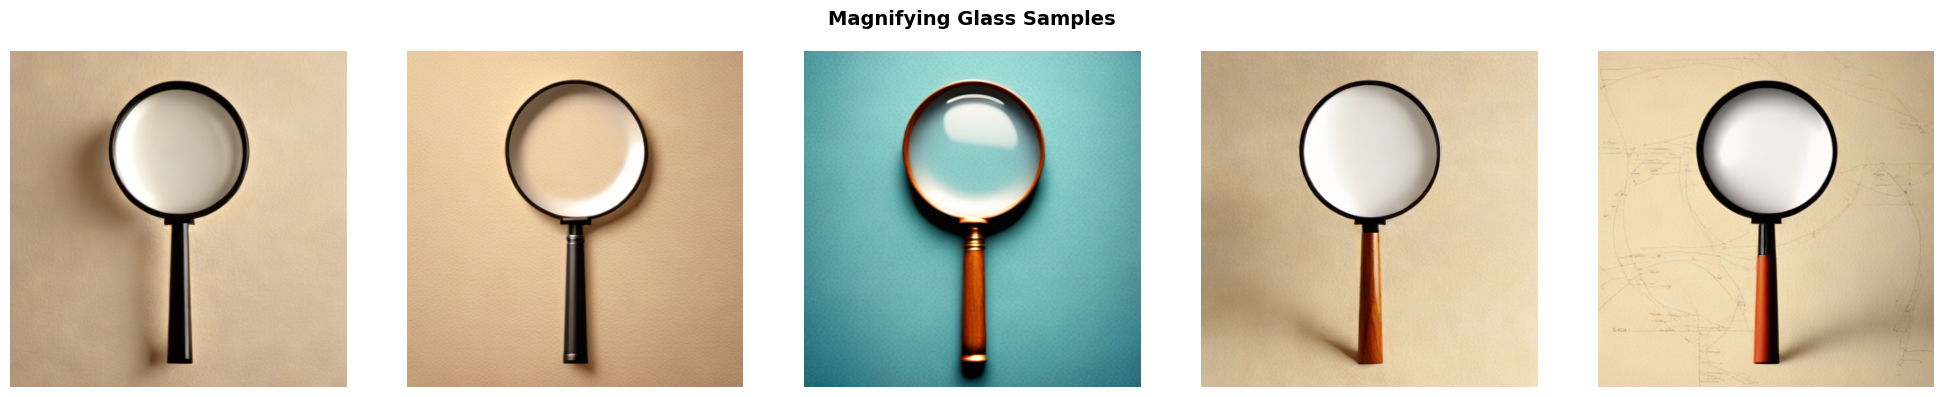

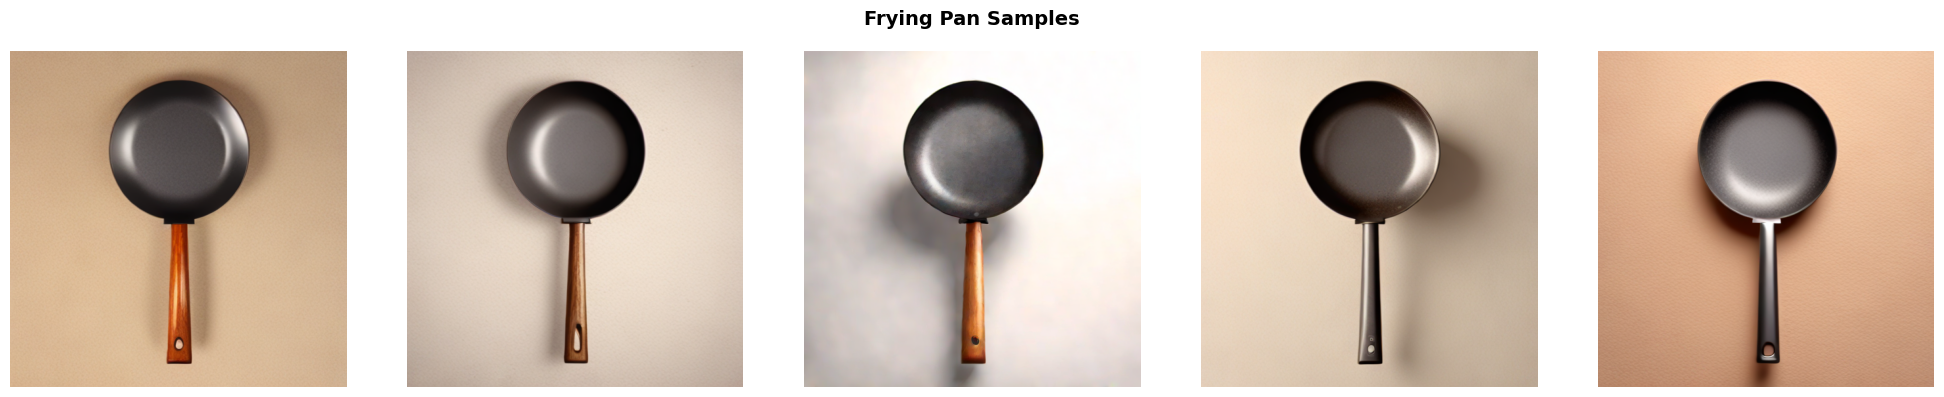

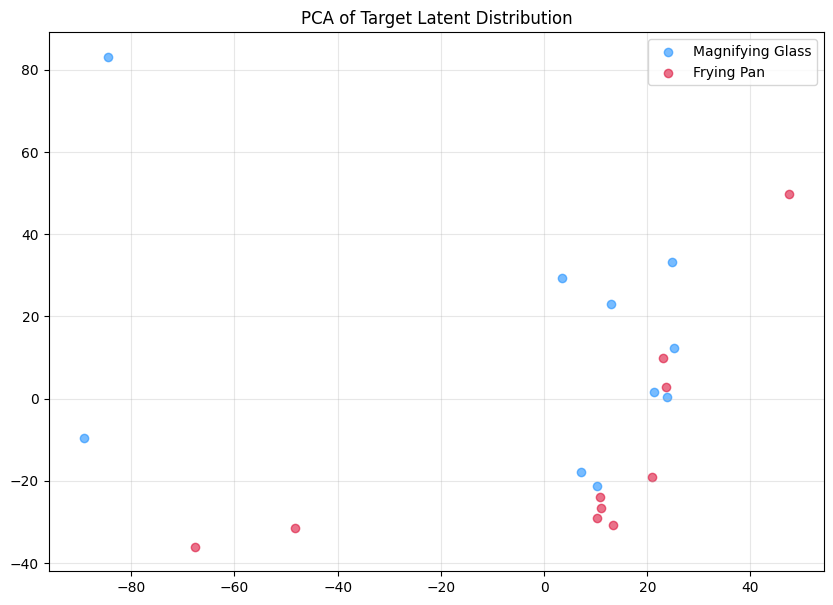

In [ ]:
n_total = N // 2
with torch.no_grad():
    mag_images, mag_latents = generate_and_store(
        sprinter, "a superrealistic magnifying glass single object",
        sobel_cond_pil, n_total, batch_size=2
    )
    pan_images, pan_latents = generate_and_store(
        sprinter, "a superrealistic pan single object",
        sobel_cond_pil, n_total, batch_size=2
    )
all_latents = np.vstack([mag_latents, pan_latents])

# Quick visual + PCA
def plot_row(images, title, count=5):
    fig, axes = plt.subplots(1, count, figsize=(4 * count, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i in range(min(count, len(images))):
        axes[i].imshow(images[i]); axes[i].axis('off')
    plt.tight_layout(); plt.show()

plot_row(mag_images, "Magnifying Glass Samples")
plot_row(pan_images, "Frying Pan Samples")


pca_viz = PCA(n_components=2)
coords = pca_viz.fit_transform(all_latents)
plt.figure(figsize=(10, 7))
plt.scatter(coords[:n_total, 0], coords[:n_total, 1], c='dodgerblue', label='Magnifying Glass', alpha=0.6)
plt.scatter(coords[n_total:, 0], coords[n_total:, 1], c='crimson', label='Frying Pan', alpha=0.6)
plt.title("PCA of Target Latent Distribution"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()


Sanity check that the conditioanl generation with the base image can generate pan and magnifier without text prompt

  0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

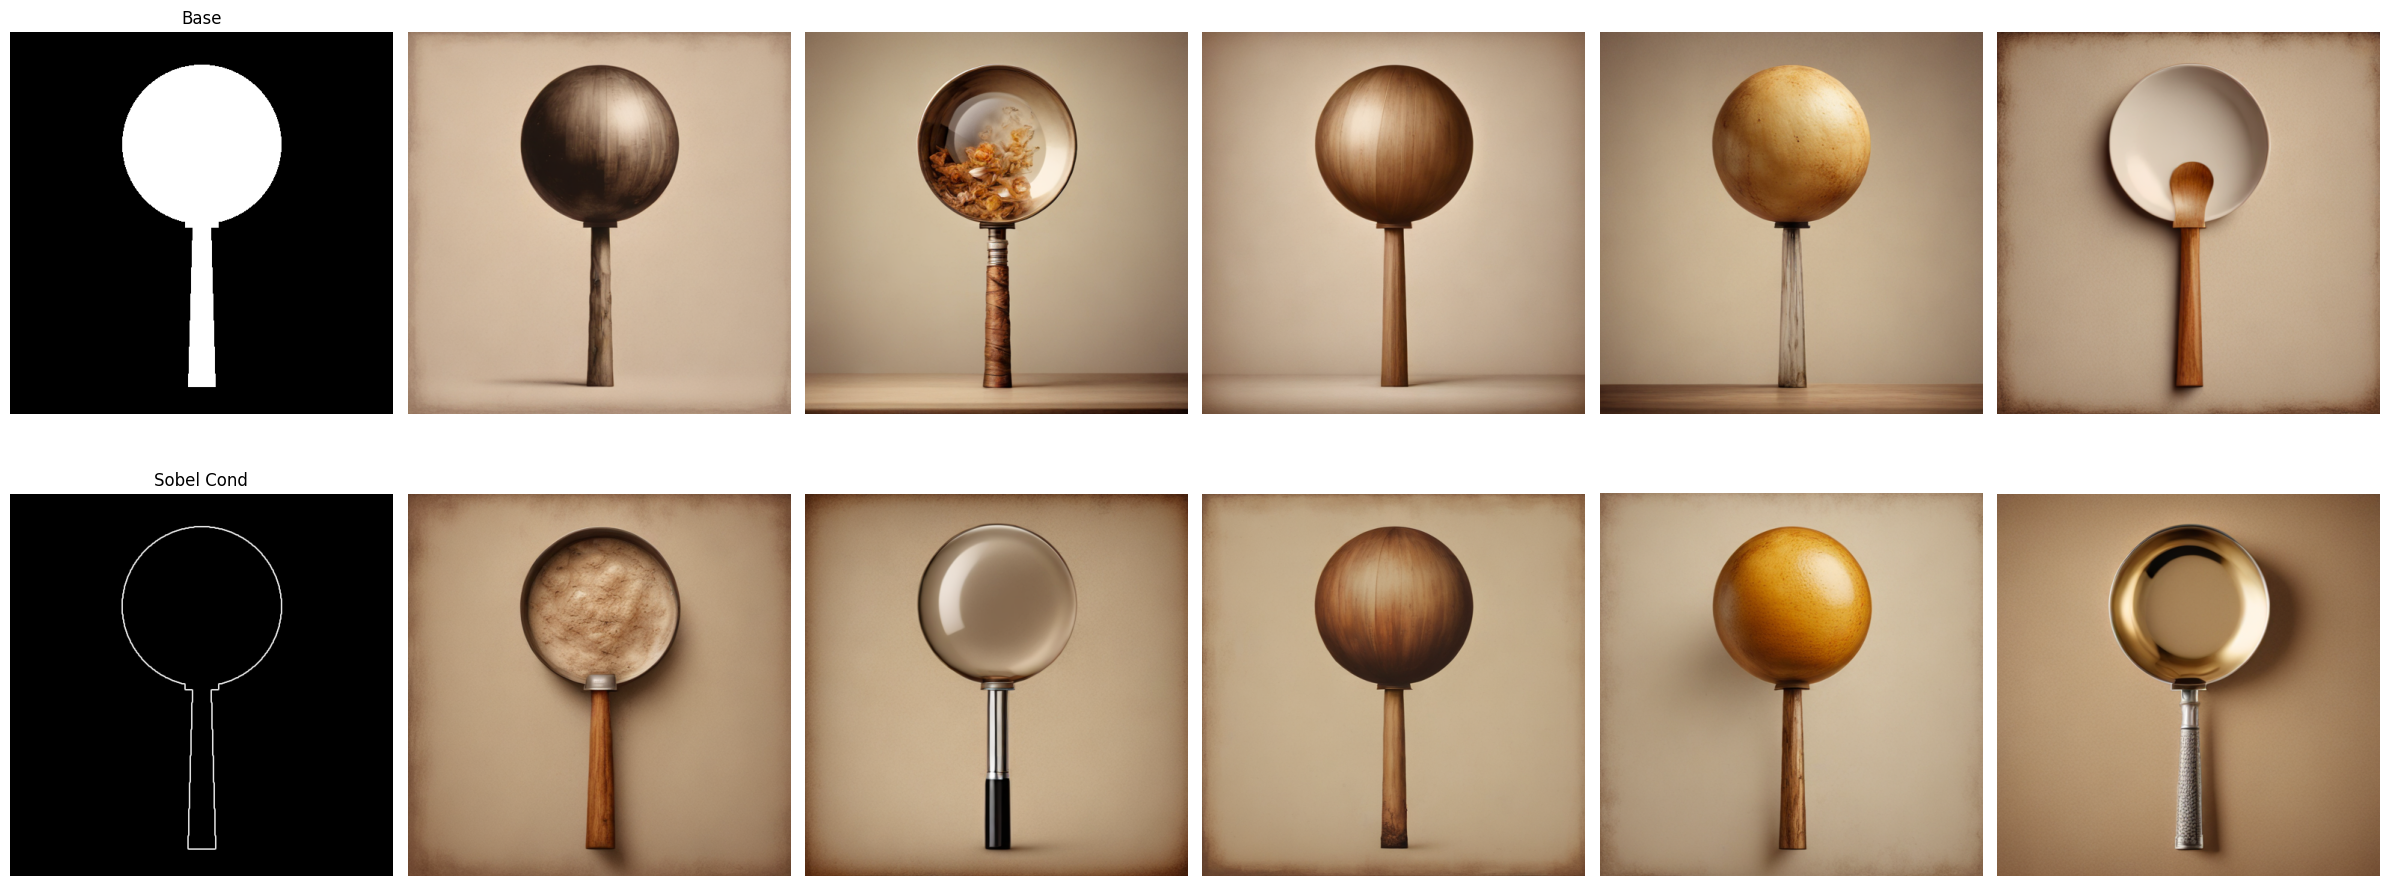

In [ ]:
rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols + 1, figsize=(24, 10))
axes[0, 0].imshow(base_image_pil); axes[0, 0].set_title("Base"); axes[0, 0].axis('off')
axes[1, 0].imshow(sobel_cond_pil); axes[1, 0].set_title("Sobel Cond"); axes[1, 0].axis('off')

seed_families = [range(100, 105), range(900, 905)]
sprinter.vae.to(dtype=torch.float16)
with torch.no_grad():
    for row_idx, seeds in enumerate(seed_families):
        for col_idx, seed in enumerate(seeds):
            output = sprinter(

                image=sobel_cond_pil,
                prompt="a superrealistic professional photograph of",
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=0.9,
            ).images[0]
            axes[row_idx, col_idx + 1].imshow(output)
            axes[row_idx, col_idx + 1].axis('off')


plt.tight_layout(); plt.show()

### Generate Architect Scribble

see that this is indeed scribble

  0%|          | 0/50 [00:00<?, ?it/s]

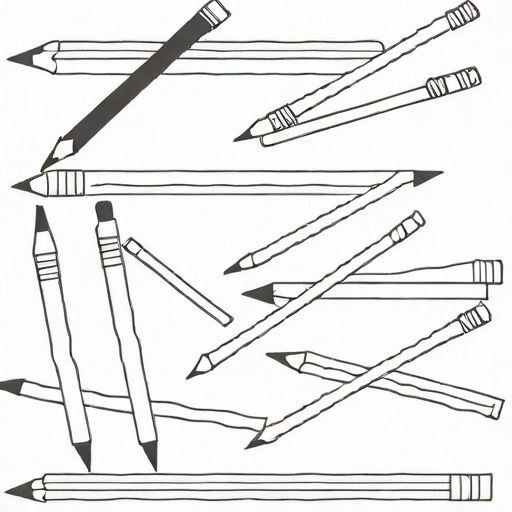

In [ ]:
scribble_prompts = [
    "minimalist scribble sketch, single black line drawing, white background, simple doodle",
    "crude stick figure scribble, child's drawing style, black pen on white paper",
    "rough pencil scribble outline, loose sketch, minimal line art",
    "abstract scribble drawing, messy lines, hand-drawn doodle on white",
]

scribble_latents = architect(
    prompt=scribble_prompts[2],
    negative_prompt="detailed, realistic, photograph, complex, colored, shading",
    num_inference_steps=50,
    guidance_scale=7.5,
    output_type="latent",
).images

with torch.no_grad():
    pixels = architect.vae.decode(scribble_latents.to(torch.float32) / 0.13025).sample
    control_image = architect.image_processor.postprocess(pixels, output_type="pil")[0]

display(control_image)

### Optimization

config

In [ ]:
# --- Config ---
sprinter.vae.to(dtype=torch.float32)
num_variations = N
variation_batch_size = 1
base_zeta_prime = 1.0
n_steps = 30
prompt = scribble_prompts[2]
negative_prompt = "detailed, realistic, photograph, complex, colored, shading"
guidance_scale = 7.5
height, width = 512, 512


prerequisites



In [ ]:
# Enable gradient checkpointing
architect.unet.enable_gradient_checkpointing()
sprinter.unet.enable_gradient_checkpointing()
sprinter.controlnet.enable_gradient_checkpointing()

# Freeze all params (we only grad through latents)
for m in [architect.unet, architect.vae, sprinter.unet, sprinter.controlnet, sprinter.vae]:
    freeze_module(m)

# --- Embeddings ---
with torch.no_grad():
    prompt_embeds, negative_prompt_embeds, pooled_prompt_embeds, negative_pooled_prompt_embeds = (
        architect.encode_prompt(
            prompt=prompt,
            negative_prompt=negative_prompt,
            device=device,
            do_classifier_free_guidance=True,
            num_images_per_prompt=1,
        )
    )

# --- Latents ---
architect.scheduler.set_timesteps(n_steps, device=device)
timesteps = architect.scheduler.timesteps

latents = architect.prepare_latents(
    1, architect.unet.config.in_channels,
    height, width, prompt_embeds.dtype, device, None
)
latents_regular = latents.detach().clone()  # parallel no-DPS baseline

# --- SDXL added_cond_kwargs (text_embeds + time_ids) ---
add_time_ids = torch.tensor(
    [[height, width, 0, 0, height, width]], dtype=prompt_embeds.dtype, device=device
)
added_cond_kwargs = {
    "text_embeds": torch.cat([negative_pooled_prompt_embeds, pooled_prompt_embeds], dim=0),
    "time_ids": add_time_ids.repeat(2, 1),
}

# --- Target distribution (flattened for PCA) ---
all_latents_flat = all_latents.reshape(all_latents.shape[0], -1)
if isinstance(all_latents_flat, torch.Tensor):
    all_latents_flat = all_latents_flat.cpu().numpy()

# --- CFG encoder_hidden_states (reused every step) ---
cfg_encoder_states = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

step_gradients = []


function to visualize the conditional optimization

In [ ]:
def visualize_step(sd, architect, sprinter, all_latents_flat, num_cond=4):
    """Render one step's visualization. Conditional images use random seeds."""
    i = sd['step']

    with torch.no_grad():
        img_xt_reg = latent_to_pil(sd['latents_step_regular_cpu'].to(device), architect.vae, architect.image_processor)
        img_x0_reg = latent_to_pil(sd['pred_x0_regular_cpu'].to(device), architect.vae, architect.image_processor)
        img_xt_dps = latent_to_pil(sd['latents_step_cpu'].to(device), architect.vae, architect.image_processor)
        img_x0_dps = latent_to_pil(sd['pred_x0_cpu'].to(device), architect.vae, architect.image_processor)

        pred_x0_dev = sd['pred_x0_cpu'].to(device)
        px = architect.vae.decode(pred_x0_dev.to(architect.vae.dtype) / architect.vae.config.scaling_factor).sample
        px_norm = torch.clamp((px + 1.0) / 2.0, 0.0, 1.0)

        sprinter.vae.to(dtype=torch.float16)
        cond_imgs = []
        for _ in range(num_cond):
            out = sprinter(
                prompt="a superrealistic professional photograph of",
                image=px_norm,
                num_inference_steps=2, guidance_scale=0.0,
                controlnet_conditioning_scale=0.8, output_type="pil", return_dict=True,
            ).images[0]
            cond_imgs.append(out)
        sprinter.vae.to(dtype=torch.float32)

        combined = np.vstack([all_latents_flat, sd['variation_latents_flat']])
        pca = PCA(n_components=2)
        pca_coords = pca.fit_transform(combined)
        target_pca = pca_coords[:all_latents_flat.shape[0]]
        gen_pca = pca_coords[all_latents_flat.shape[0]:]

    fig, axes = plt.subplots(2, 7, figsize=(28, 8))
    fig.suptitle(f"Step {i+1}  (t={sd['timestep']:.0f})", fontsize=14, fontweight='bold')

    axes[0, 0].imshow(img_xt_reg); axes[0, 0].set_title("Regular x_t")
    axes[0, 1].imshow(img_x0_reg); axes[0, 1].set_title("Regular pred x_0")
    for j in range(2, 7):
        axes[0, j].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[0, j].transAxes)
        axes[0, j].set_facecolor('#f0f0f0')

    axes[1, 0].imshow(img_xt_dps); axes[1, 0].set_title(f"DPS x_t  ζ={sd['zeta_i']:.4f}")
    axes[1, 1].imshow(img_x0_dps); axes[1, 1].set_title(f"DPS x_0  MMD={sd['mmd_loss']:.6f}")
    for j, ci in enumerate(cond_imgs):
        axes[1, j + 2].imshow(ci); axes[1, j + 2].set_title(f"Cond {j+1}")

    axes[1, 6].scatter(target_pca[:, 0], target_pca[:, 1], c='blue', alpha=0.5, s=20, label='Target')
    axes[1, 6].scatter(gen_pca[:, 0], gen_pca[:, 1], c='red', alpha=0.6, s=30, marker='x', label='Generated')
    axes[1, 6].set_title(f"PCA  Var={pca.explained_variance_ratio_.sum():.1%}")
    axes[1, 6].legend(fontsize=8); axes[1, 6].grid(True, alpha=0.3)

    for row in axes:
        for ax in row:
            ax.axis("off")
    axes[1, 6].axis("on")

    plt.tight_layout(); plt.show()

Main optimization -  DPS

steps fucntions

In [ ]:
def run_dps_step(i, t, latents, latents_step, noise_pred, pixel_x0_norm):
    """Run sprinter variations + MMD + DPS gradient. Returns grad, mmd, zeta, variation data."""
    variation_latents_list = []
    print(f"  Generating {num_variations} variations...")

    for start_idx in range(0, num_variations, variation_batch_size):
        end_idx = min(start_idx + variation_batch_size, num_variations)
        bs = end_idx - start_idx
        ctrl_batch = pixel_x0_norm[0].unsqueeze(0).repeat(bs, 1, 1, 1)

        def sprinter_forward(ctrl):
            return sprinter(
                prompt=["a superrealistic professional photograph of"] * ctrl.shape[0],
                image=ctrl, num_inference_steps=2, guidance_scale=0.0,
                controlnet_conditioning_scale=0.8, output_type="latent", return_dict=True,
            ).images

        with torch.cuda.amp.autocast():
            vl = torch.utils.checkpoint.checkpoint(
                sprinter_forward, ctrl_batch, use_reentrant=False
            )
        variation_latents_list.append(vl)
        torch.cuda.empty_cache()

    variation_latents = torch.cat(variation_latents_list, dim=0)


    mmd_squared = compute_mmd(variation_latents, all_latents, kernel='rbf')
    mmd_loss = torch.sqrt(mmd_squared + 1e-8)
    loss_norm = mmd_loss.detach()
    zeta_i = base_zeta_prime / loss_norm


    grad = torch.autograd.grad(mmd_loss, latents_step, retain_graph=False, create_graph=False)[0]

    vl_flat = variation_latents.detach().cpu().numpy().reshape(variation_latents.shape[0], -1)

    del variation_latents_list, variation_latents

    return grad, mmd_loss, zeta_i, loss_norm, vl_flat




def denoise_step(scheduler, noise_pred, t, latents_in, correction=None):
    """Single scheduler step. DPS correction applied AFTER step (per paper)."""
    x_t_minus_1 = scheduler.step(noise_pred, t, latents_in, return_dict=True).prev_sample
    if correction is not None:
        x_t_minus_1 = x_t_minus_1 + correction
    return x_t_minus_1.detach()



def predict_noise_cfg(unet, scheduler, latents_in, t, encoder_states, added_cond, gs):
    """CFG noise prediction."""
    lmi = scheduler.scale_model_input(torch.cat([latents_in] * 2), t)
    np_out = unet(lmi, t, encoder_hidden_states=encoder_states,
                  added_cond_kwargs=added_cond, return_dict=False)[0]
    np_u, np_t = np_out.chunk(2)
    return np_u + gs * (np_t - np_u)


def compute_pred_x0(scheduler, noise_pred, t, latents_in):
    """Get pred_x0 from scheduler step or manual formula."""
    so = scheduler.step(noise_pred, t, latents_in, return_dict=True)
    if hasattr(so, 'pred_original_sample') and so.pred_original_sample is not None:
        return so.pred_original_sample
    alpha = scheduler.alphas_cumprod[t.long().cpu()].to(latents_in.device)
    return (latents_in - (1 - alpha)**0.5 * noise_pred) / alpha**0.5

loop over all steps

Beginning DPS Denoising (30 steps, 20 variations/step)...

Step 1/30 (t=999.0)
  Generating 20 variations...


/tmp/ipython-input-2147727886.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  MMD=0.407532  ζi=2.4538  ∥∇∥=0.001813


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

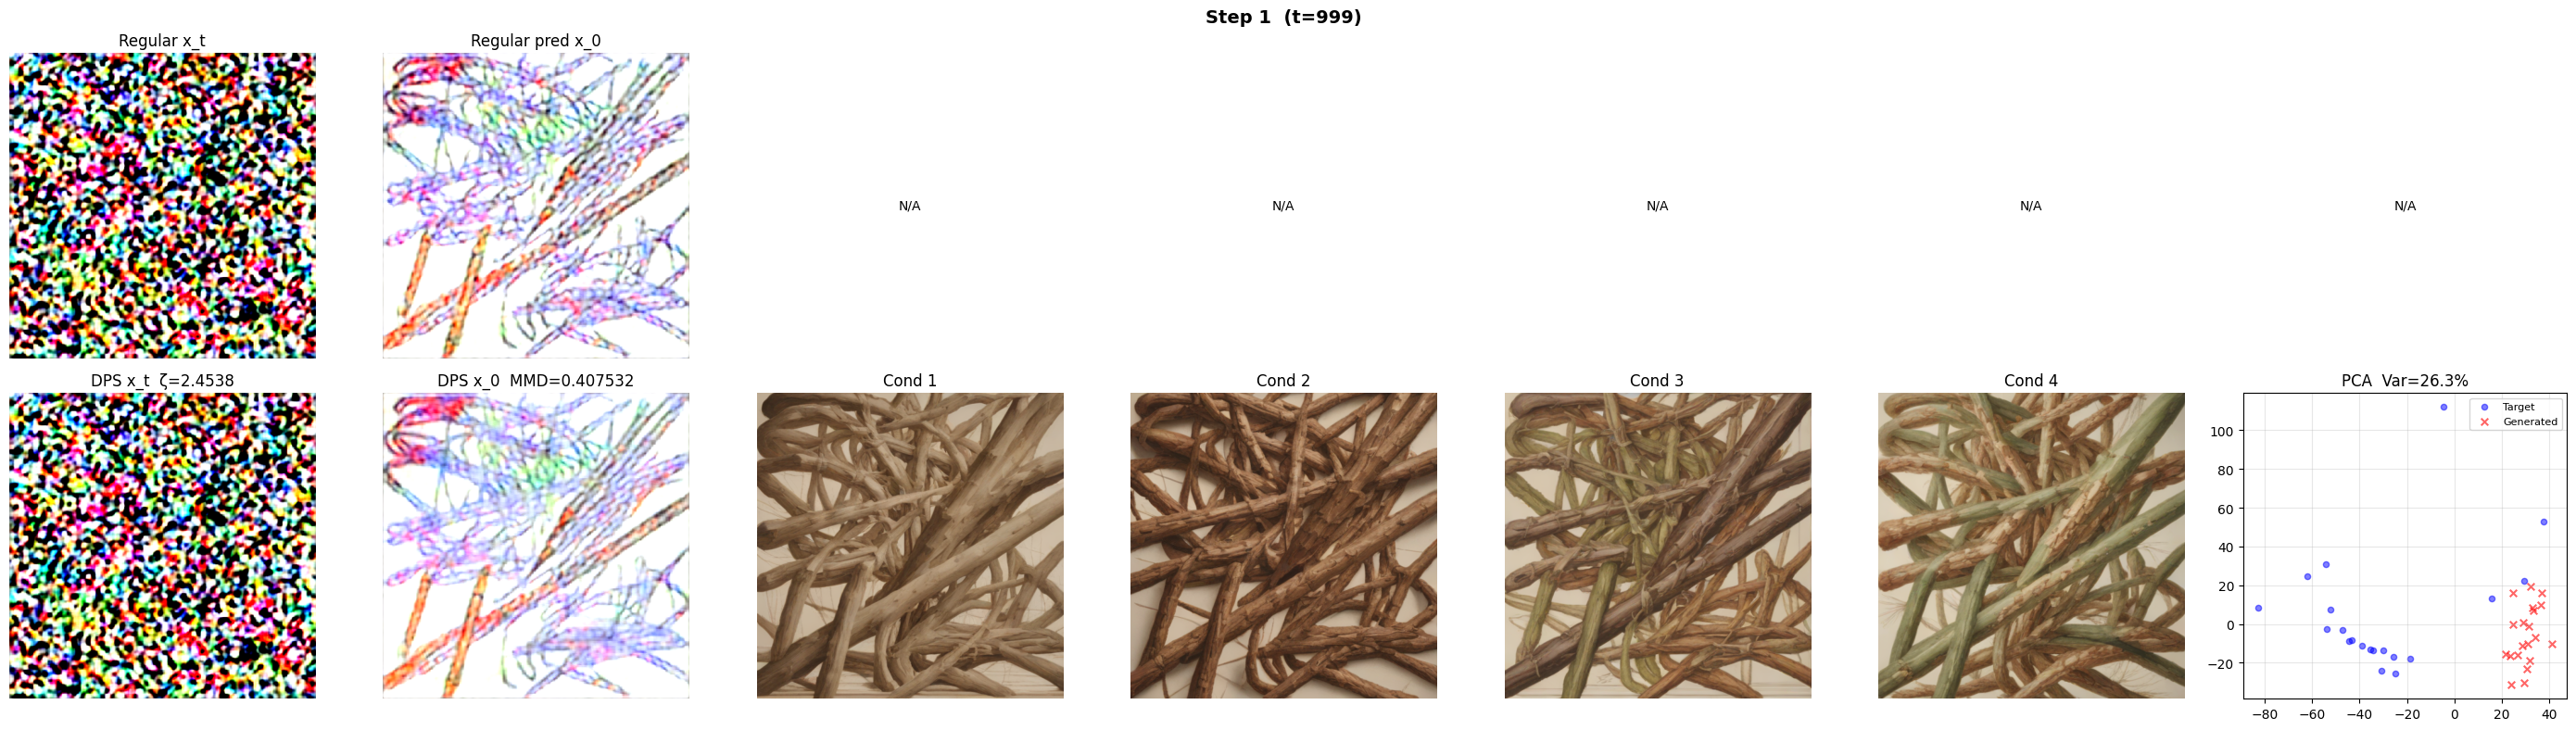


Step 2/30 (t=966.0)
  Generating 20 variations...


/tmp/ipython-input-2147727886.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
print(f"Beginning DPS Denoising ({n_steps} steps, {num_variations} variations/step)...")

step_vis_data = []

for i, t in enumerate(timesteps):
    print(f"\n{'='*60}\nStep {i+1}/{n_steps} (t={t})\n{'='*60}")

    latents_step = latents.detach().requires_grad_(True)
    latents_step_regular = latents_regular.detach()

    # --- A. Noise prediction (both paths) ---
    noise_pred = predict_noise_cfg(
        architect.unet, architect.scheduler, latents_step, t,
        cfg_encoder_states, added_cond_kwargs, guidance_scale
    )

    with torch.no_grad():
        noise_pred_regular = predict_noise_cfg(
            architect.unet, architect.scheduler, latents_step_regular, t,
            cfg_encoder_states, added_cond_kwargs, guidance_scale
        )

    # --- B. Compute pred_x0 (both paths) ---
    pred_x0 = compute_pred_x0(architect.scheduler, noise_pred, t, latents_step)

    with torch.no_grad():
        pred_x0_regular = compute_pred_x0(architect.scheduler, noise_pred_regular, t, latents_step_regular)

    # --- C. Decode pred_x0 → pixel space ---
    pred_x0_scaled = pred_x0 / architect.vae.config.scaling_factor

    def vae_decode_checkpoint(lat):
        return architect.vae.decode(lat.to(architect.vae.dtype)).sample

    pixel_x0 = torch.utils.checkpoint.checkpoint(
        vae_decode_checkpoint, pred_x0_scaled, use_reentrant=False
    )
    pixel_x0_norm = torch.clamp((pixel_x0 + 1.0) / 2.0, 0.0, 1.0)

    # --- D. DPS: variations + MMD + gradient ---
    grad, mmd_loss, zeta_i, loss_norm, vl_flat = run_dps_step(
        i, t, latents, latents_step, noise_pred, pixel_x0_norm
    )
    grad_norm = grad.norm().item()
    print(f"  MMD={mmd_loss.item():.6f}  ζi={zeta_i:.4f}  ∥∇∥={grad_norm:.6f}")

    step_gradients.append({
        'step': i, 'timestep': t.item(), 'gradient_norm': grad_norm,
        'mmd_loss': mmd_loss.item(),
        'zeta_i': zeta_i.item() if isinstance(zeta_i, torch.Tensor) else zeta_i,
        'loss_norm': loss_norm.item(),
    })

    # --- E. Store + Visualize ---
    with torch.no_grad():
        sd = {
            'step': i,
            'timestep': t.item(),
            'mmd_loss': mmd_loss.item(),
            'zeta_i': zeta_i.item() if isinstance(zeta_i, torch.Tensor) else zeta_i,
            'latents_step_cpu': latents_step.detach().cpu(),
            'latents_step_regular_cpu': latents_step_regular.detach().cpu(),
            'pred_x0_cpu': pred_x0.detach().cpu(),
            'pred_x0_regular_cpu': pred_x0_regular.detach().cpu(),
            'variation_latents_flat': vl_flat,
        }
        step_vis_data.append(sd)
    visualize_step(sd, architect, sprinter, all_latents_flat)

    # --- F. Scheduler step (both paths) ---
    correction = -zeta_i * grad
    latents = denoise_step(architect.scheduler, noise_pred, t, latents_step, correction=correction)

    with torch.no_grad():
        latents_regular = denoise_step(architect.scheduler, noise_pred_regular, t, latents_step_regular)

    # Cleanup
    del grad, mmd_loss, loss_norm, zeta_i
    del pixel_x0, pixel_x0_norm, pred_x0, pred_x0_regular
    del latents_step_regular, noise_pred_regular
    gc.collect(); torch.cuda.empty_cache()

del latents_step, noise_pred, step_output
torch.cuda.empty_cache()

print(f"\n✅ DPS Complete! {len(step_vis_data)} steps stored.")